# Ask with a list of images

Minimal demo: send a list of images plus a text prompt to `ask_chatgpt()`.

Edit `IMAGE_PATHS` and `PROMPT` below, then run all cells.

In [1]:
print("Importing libraries...")
import sys, os
import time

sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning.chatgpt_client import ask_chatgpt

Importing libraries...


## Configure images and prompt

In [ ]:
REFERENCE_IMAGES = [
    ("skull_001", "../reference_views_medical/skull/skull_001.png", "This is the RIGHT lateral view of the skull."),
    ("skull_002", "../reference_views_medical/skull/skull_002.png", "This is the FRONT (anterior) view of the skull."),
    ("skull_003", "../reference_views_medical/skull/skull_003.png", "This is the LEFT lateral view of the skull."),
]

QUERY_IMAGES = [
    ("view_003", "../reference_views_relative/view_004.png"),
    ("view_004", "../output/screenshots/rollouts/step_001/ELEVATION_DOWN_COARSE.png"),
]

IMAGE_PATHS = [path for _, path in QUERY_IMAGES] + [path for _, path, _ in REFERENCE_IMAGES]

PROMPT = (
    "You will see two query images, query_1 and query_2, followed by three labeled "
    "reference images (skull_001, skull_002, skull_003), each with a short description "
    "telling you exactly which view it is. The very first image shown is query_1, and it "
    "is immediately followed by a text label '[query_2]' and the second query image.\n\n"
    "Using the reference images to calibrate left vs. right, tell me: is query_1 a LEFT "
    "lateral or RIGHT lateral view of the skull? Is query_2 a LEFT lateral or RIGHT "
    "lateral view? Explain the visual cues you used to decide."
)

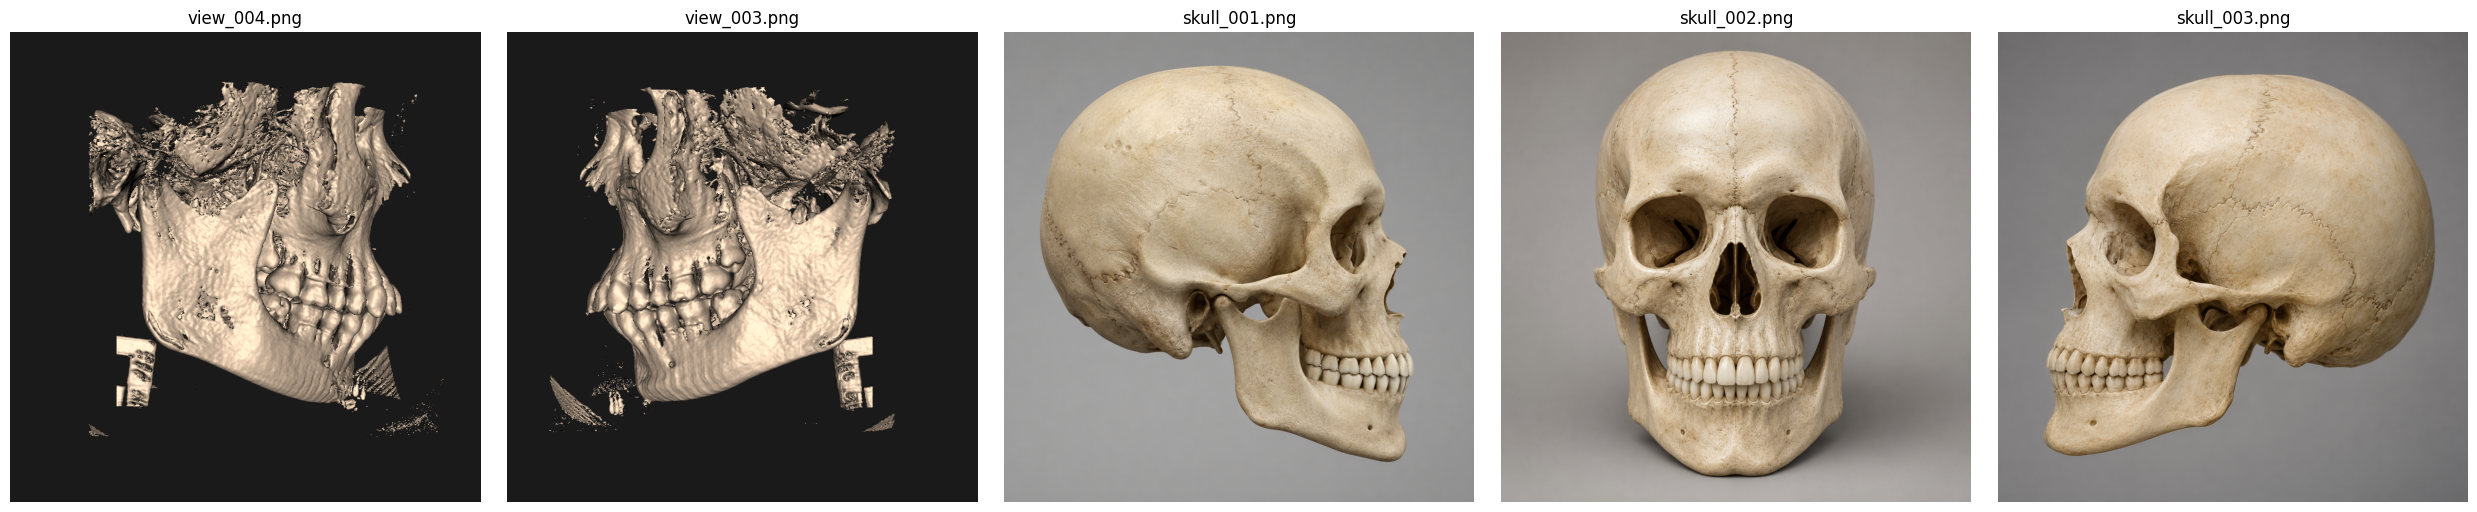

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(5 * len(IMAGE_PATHS), 5))
if len(IMAGE_PATHS) == 1:
    axes = [axes]

for ax, path in zip(axes, IMAGE_PATHS):
    ax.imshow(Image.open(path))
    ax.set_title(os.path.basename(path))
    ax.axis("off")

plt.tight_layout()
plt.show()

## Run

In [7]:
# The first query image goes in screenshot_path (unlabeled, referred to as
# "the very first image" in the prompt); the second query image and the three
# skull references are all labeled so the model can refer back to them by name.
screenshot_path = QUERY_IMAGES[0][1]
extra_images = [QUERY_IMAGES[1]]

print("LLM starts processing...")
start = time.perf_counter()
response = ask_chatgpt(
    prompt=PROMPT,
    screenshot_path=screenshot_path,
    extra_images=extra_images,
    reference_items=REFERENCE_IMAGES,
)
elapsed = time.perf_counter() - start

print(response)
print(f"\n[Elapsed: {elapsed:.2f}s]")

LLM starts processing...
Looking at the reference images to establish orientation:

- **skull_001** (RIGHT lateral): Shows the right side with the face pointing right
- **skull_003** (LEFT lateral): Shows the left side with the face pointing left

Now analyzing the query images:

## Query_1 Analysis:
**Query_1 is a RIGHT lateral view**

Visual cues:
- The face/anterior portion of the skull is oriented toward the right side of the image
- The posterior cranium (back of skull) is on the left side of the image
- The mandible and maxilla with visible teeth are positioned on the right
- This orientation matches skull_001 (the labeled RIGHT lateral view)

## Query_2 (view_004) Analysis:
**Query_2 is a LEFT lateral view**

Visual cues:
- The face/anterior portion of the skull is oriented toward the LEFT side of the image
- The posterior cranium is on the right side of the image
- The mandible and teeth-bearing portions are positioned on the left
- This orientation matches skull_003 (the label